# 深層強化学習トレーディングシステム - Bybit BTCUSDT Perpetual

## 主要な改善点 (v9) - Buy & Hold を超えるための最適化
1. **コンポジット報酬関数**: シャープレシオを除去し、複数のリスク指標を組み合わせた報酬設計
2. **Calmar比による選択**: シャープレシオの代わりにCalmar比（リターン/最大DD）でハイパーパラメータ選択
3. **強化された特徴量**: 市場レジーム検出、累積リターン、Order Flow Imbalance追加
4. **改良PPOパラメータ**: より大きなネットワーク（1024ユニット）、適応的学習率
5. **リスク調整報酬**: ダウンサイドリスクペナルティ、一貫性ボーナス、回復力ボーナス

## 概要
- **データ**: Bybit BTCUSDT Perpetual 1H (2020-09-01 〜 2025-08-31)
- **手法**: 5分割Walk-Forward Optimization (WFO)
- **アルゴリズム**: PPO (stable-baselines3) with risk-aware rewards
- **評価**: Calmar比、Sortino比、最大ドローダウン、累積リターン
- **ベンチマーク**: Buy & Hold戦略との比較
- **取引コスト**: 手数料0%（要求仕様通り）

### 実行環境
- Google Colab（GPU推奨）
- 実行時間: 約60-120分（GPUあり、動的timesteps使用）

## 1. セットアップ - ライブラリインストールと初期設定

In [4]:
# 安定版セットアップ（依存性固定・互換性対応）
# 1) 既知の衝突パッケージを除去
!pip -q install -U pip setuptools wheel
!pip -q uninstall -y dopamine-rl || true
!pip -q uninstall -y gym || true

# 2) コア依存の固定（SB3 2.3.x と互換の Gymnasium 系）
!pip -q install gymnasium==0.29.1 stable-baselines3==2.3.2

# 3) 科学計算・可視化系（必要十分な範囲）
!pip -q install "numpy>=1.23" "pandas>=2.0" matplotlib plotly scikit-learn

# 4) テクニカル指標（PEP517でビルド安定化）
!pip -q install ta==0.11.0 --use-pep517

# 5) リスク指標（py3.12対応フォーク）
!pip -q install empyrical-reloaded

print("✅ セットアップ完了")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ セットアップ完了


In [5]:
# 必要なライブラリのインストール
!pip install -q --upgrade pip
!pip install -q stable-baselines3==2.3.2
!pip install -q gymnasium==0.28.1
!pip install -q pandas numpy matplotlib plotly
!pip install -q ta scikit-learn
!pip install -q empyrical==0.5.5

print("✅ ライブラリのインストール完了")

# インポート
import os
import sys
import random
import warnings
import pickle
import json
from typing import Dict, List, Tuple, Optional, Any, Union
from dataclasses import dataclass, field
from datetime import datetime, timedelta
import time
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# テクニカル指標
import ta
from sklearn.preprocessing import StandardScaler, RobustScaler

# 強化学習
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO, A2C, SAC
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy

# 評価指標
import empyrical as ep

# 警告を抑制
warnings.filterwarnings('ignore')

# 乱数シード固定
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# PyTorchがある場合はシード固定
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
except ImportError:
    pass

# GPU確認
try:
    import torch
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️  Device: {device}")
    if device.type == 'cuda':
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
except:
    print("🖥️  Device: CPU")

print("✅ セットアップ完了")

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
✅ ライブラリのインストール完了


/usr/local/lib/python3.12/dist-packages/pandas_datareader/compat/__init__.py:11: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  PANDAS_VERSION = LooseVersion(pd.__version__)


🖥️  Device: cpu
✅ セットアップ完了


## 2. データロード - Google DriveまたはUpload

In [7]:
# Google Colab環境の確認
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🌐 Google Colab環境を検出")

    # オプション1: Google Driveマウント
    from google.colab import drive, files

    use_drive = input("Google Driveを使用しますか？ (y/n): ").lower() == 'y'

    if use_drive:
        drive.mount('/content/drive')
        # Driveのパスを設定（ユーザーが調整）
        DATA_PATH = '/content/drive/MyDrive/Colab/強化学習トレーディング/data/bybit_btcusdt_perp_1h_20200901_20250831.pkl'
    else:
        # オプション2: ファイルアップロード
        print("📂 ファイルをアップロードしてください")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
else:
    # ローカル環境
    DATA_PATH = '/Users/aimitmk/Documents/2025_松尾研/深層強化学習/data/bybit_btcusdt_perp_1h_20200901_20250831.pkl'

# パラメータ設定（重要: 手数料を0に設定）
TAKER_FEE = 0.0000  # 手数料0%（要求仕様通り）
ANNUALIZATION = 8760  # 1時間足の年率換算（24*365）
EXECUTION_PRICE = 'next_open'  # 'next_open' or 'next_close'
INITIAL_CAPITAL = 1.0  # 初期資金（正規化）
LEVERAGE = 1.0  # レバレッジ

print(f"\n📁 Data path: {DATA_PATH}")
print(f"💰 Taker fee: {TAKER_FEE*100:.2f}% (手数料なし)")
print(f"📊 Execution: {EXECUTION_PRICE}")

🌐 Google Colab環境を検出
Google Driveを使用しますか？ (y/n): y
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📁 Data path: /content/drive/MyDrive/Colab/強化学習トレーディング/data/bybit_btcusdt_perp_1h_20200901_20250831.pkl
💰 Taker fee: 0.00% (手数料なし)
📊 Execution: next_open


In [8]:
def load_and_preprocess_data(file_path: str) -> pd.DataFrame:
    """データの読み込みと前処理

    Args:
        file_path: データファイルのパス

    Returns:
        pd.DataFrame: 前処理済みデータ
    """
    # データ読み込み
    if file_path.endswith('.pkl'):
        df = pd.read_pickle(file_path)
    elif file_path.endswith('.csv'):
        df = pd.read_csv(file_path)
    else:
        raise ValueError(f"Unsupported file format: {file_path}")

    # 列名の正規化（大文字→小文字）
    df.columns = df.columns.str.lower()

    # 必須列の確認
    required_cols = ['open', 'high', 'low', 'close', 'volume']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # datetime列の処理
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df = df.set_index('datetime')
    elif 'timestamp' in df.columns:
        if df['timestamp'].dtype == 'int64':
            df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
        else:
            df['datetime'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('datetime')
    elif not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("No datetime information found")

    # 時系列順にソート
    df = df.sort_index()

    # 欠損値の処理
    if df.isnull().sum().sum() > 0:
        print(f"⚠️  Found {df.isnull().sum().sum()} NaN values. Forward filling...")
        df = df.fillna(method='ffill').fillna(method='bfill')

    print(f"✅ Loaded data: {len(df):,} rows")
    print(f"📅 Period: {df.index[0]} to {df.index[-1]}")
    print(f"📊 Columns: {list(df.columns)}")

    return df

# データ読み込み
try:
    df_raw = load_and_preprocess_data(DATA_PATH)
    print("\n📊 Data Statistics:")
    print(df_raw[['open', 'high', 'low', 'close', 'volume']].describe())
except FileNotFoundError:
    print("❌ ファイルが見つかりません。サンプルデータを生成します...")
    # サンプルデータ生成（デモ用）
    date_range = pd.date_range('2020-09-01', '2025-08-31 23:00:00', freq='1h')
    np.random.seed(SEED)

    # ランダムウォークでBTC価格をシミュレート
    returns = np.random.normal(0.0001, 0.01, len(date_range))
    prices = 10000 * np.exp(np.cumsum(returns))

    df_raw = pd.DataFrame({
        'open': prices * (1 + np.random.normal(0, 0.001, len(prices))),
        'high': prices * (1 + np.abs(np.random.normal(0, 0.005, len(prices)))),
        'low': prices * (1 - np.abs(np.random.normal(0, 0.005, len(prices)))),
        'close': prices,
        'volume': np.random.lognormal(10, 2, len(prices))
    }, index=date_range)

    print("✅ サンプルデータを生成しました")

✅ Loaded data: 43,824 rows
📅 Period: 2020-09-01 00:00:00+00:00 to 2025-08-31 23:00:00+00:00
📊 Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume']

📊 Data Statistics:
                open           high            low          close  \
count   43824.000000   43824.000000   43824.000000   43824.000000   
mean    48507.202063   48705.646459   48301.867121   48509.407053   
std     27719.893511   27802.646226   27636.374003   27720.801621   
min      9957.000000   10029.500000    9834.000000    9957.000000   
25%     26817.575000   26871.600000   26738.825000   26817.700000   
50%     42091.750000   42259.750000   41879.000000   42093.000000   
75%     63337.250000   63612.625000   63048.875000   63344.050000   
max    123889.200000  124571.200000  123375.000000  123889.200000   

              volume  
count   43824.000000  
mean     4280.451378  
std      5856.405088  
min        15.628000  
25%      1282.272000  
50%      2483.650000  
75%      4988.203750  
max    170105.7

## 3. 強化された特徴量生成 - v9改善版（レジーム検出、Order Flow追加）

In [9]:
def generate_enhanced_features_v9(df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    """v9改善版: 市場レジーム検出とOrder Flow Imbalanceを追加した特徴量生成

    Args:
        df: OHLCVデータ

    Returns:
        tuple: (特徴量付きデータ, 特徴量列名リスト)
    """
    df = df.copy()

    # ===== リターン（無次元化済み） =====
    df['ret_1h'] = df['close'].pct_change()
    df['ret_4h'] = df['close'].pct_change(4)
    df['ret_12h'] = df['close'].pct_change(12)
    df['ret_24h'] = df['close'].pct_change(24)
    df['ret_48h'] = df['close'].pct_change(48)
    df['ret_168h'] = df['close'].pct_change(168)  # 1週間リターン

    # ===== 累積リターン（v9新規） =====
    df['cumret_24h'] = (df['close'] / df['close'].shift(24) - 1).fillna(0)
    df['cumret_168h'] = (df['close'] / df['close'].shift(168) - 1).fillna(0)

    # ===== ボラティリティ（標準偏差は無次元） =====
    df['vol_24h'] = df['ret_1h'].rolling(24).std()
    df['vol_72h'] = df['ret_1h'].rolling(72).std()
    df['vol_168h'] = df['ret_1h'].rolling(168).std()  # 1週間

    # ボラティリティの変化率
    df['vol_ratio_24_72'] = df['vol_24h'] / df['vol_72h'].replace(0, np.nan)
    df['vol_ratio_24_168'] = df['vol_24h'] / df['vol_168h'].replace(0, np.nan)

    # ===== Realized Volatility（暗号通貨向け） =====
    df['realized_vol_24h'] = np.sqrt((df['ret_1h']**2).rolling(24).sum())
    df['realized_vol_168h'] = np.sqrt((df['ret_1h']**2).rolling(168).sum())

    # ===== 市場レジーム検出（v9新規） =====
    # トレンド強度
    sma_20 = ta.trend.sma_indicator(df['close'], window=20)
    sma_50 = ta.trend.sma_indicator(df['close'], window=50)
    sma_200 = ta.trend.sma_indicator(df['close'], window=200)

    df['trend_strength'] = ((df['close'] > sma_20).astype(float) +
                            (df['close'] > sma_50).astype(float) +
                            (df['close'] > sma_200).astype(float)) / 3.0

    # レンジ/トレンド判定（ADXベース）
    adx = ta.trend.ADXIndicator(high=df['high'], low=df['low'], close=df['close'], window=14)
    df['adx'] = adx.adx() / 100  # 0-1に正規化
    df['regime_trending'] = (df['adx'] > 0.25).astype(float)  # ADX > 25でトレンド

    # ===== Order Flow Imbalance（v9新規） =====
    # 買い圧力の推定（Close位置ベース）
    df['buying_pressure'] = (df['close'] - df['low']) / (df['high'] - df['low']).replace(0, np.nan)
    df['selling_pressure'] = (df['high'] - df['close']) / (df['high'] - df['low']).replace(0, np.nan)
    df['order_flow_imbalance'] = df['buying_pressure'] - df['selling_pressure']

    # ボリューム加重Order Flow
    df['volume_weighted_flow'] = df['order_flow_imbalance'] * (df['volume'] / df['volume'].rolling(24).mean())

    # ===== RSI（0-100の範囲、無次元） =====
    df['rsi_14'] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()
    df['rsi_30'] = ta.momentum.RSIIndicator(close=df['close'], window=30).rsi()
    df['rsi_7'] = ta.momentum.RSIIndicator(close=df['close'], window=7).rsi()

    # RSIを0-1の範囲に正規化
    df['rsi_14'] = df['rsi_14'] / 100
    df['rsi_30'] = df['rsi_30'] / 100
    df['rsi_7'] = df['rsi_7'] / 100

    # ===== MACD（正規化版） =====
    macd = ta.trend.MACD(close=df['close'], window_slow=26, window_fast=12, window_sign=9)
    df['macd_diff_normalized'] = macd.macd_diff() / df['close']  # 価格で正規化
    df['macd_signal_normalized'] = macd.macd_signal() / df['close']

    # ===== ボリンジャーバンド（無次元化） =====
    bb = ta.volatility.BollingerBands(close=df['close'], window=20, window_dev=2)
    bb_high = bb.bollinger_hband()
    bb_low = bb.bollinger_lband()
    bb_mid = bb.bollinger_mavg()

    # BBポジション（0-1の範囲）
    df['bb_position'] = (df['close'] - bb_low) / (bb_high - bb_low).replace(0, np.nan)
    df['bb_position'] = df['bb_position'].clip(0, 1)  # 0-1にクリップ

    # BB幅（相対値）
    df['bb_width'] = (bb_high - bb_low) / bb_mid

    # ===== ATR（正規化版） =====
    atr = ta.volatility.AverageTrueRange(
        high=df['high'], low=df['low'], close=df['close'], window=14
    ).average_true_range()
    df['atr_normalized'] = atr / df['close']  # 価格で正規化

    # ===== ボリューム指標（比率ベース、無次元） =====
    df['volume_ratio_24h'] = df['volume'] / df['volume'].rolling(24).mean().replace(0, np.nan)
    df['volume_ratio_168h'] = df['volume'] / df['volume'].rolling(168).mean().replace(0, np.nan)
    df['volume_trend'] = df['volume'].rolling(24).mean() / df['volume'].rolling(168).mean().replace(0, np.nan)

    # ===== On-Balance Volume (OBV) 正規化版 =====
    obv = ta.volume.OnBalanceVolumeIndicator(close=df['close'], volume=df['volume']).on_balance_volume()
    df['obv_normalized'] = (obv - obv.rolling(168).mean()) / obv.rolling(168).std().replace(0, np.nan)

    # ===== 価格の相対的な位置（無次元） =====
    # High-Low-Close関係
    df['hl_ratio'] = (df['high'] - df['low']) / df['close']
    df['hc_ratio'] = (df['high'] - df['close']) / df['close']
    df['lc_ratio'] = (df['close'] - df['low']) / df['close']

    # ===== 移動平均からの乖離（％表示、無次元） =====
    df['deviation_sma20'] = (df['close'] - sma_20) / sma_20
    df['deviation_sma50'] = (df['close'] - sma_50) / sma_50
    df['deviation_sma200'] = (df['close'] - sma_200) / sma_200

    # ===== 暗号通貨特有: Funding Rate的な指標（価格の歪み） =====
    df['price_skew'] = (df['close'] - df['open']) / df['open']
    df['price_momentum'] = df['close'].pct_change(24).rolling(24).mean()

    # ===== 時間特徴（周期性、無次元） =====
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

    # ===== Stochastic Oscillator（0-1の範囲） =====
    stoch = ta.momentum.StochasticOscillator(
        high=df['high'], low=df['low'], close=df['close'],
        window=14, smooth_window=3
    )
    df['stoch_k'] = stoch.stoch() / 100  # 0-1に正規化
    df['stoch_d'] = stoch.stoch_signal() / 100  # 0-1に正規化

    # ===== ボラティリティレジーム =====
    df['vol_regime'] = (df['vol_24h'] > df['vol_168h'].rolling(24).mean()).astype(float)

    # ===== 将来情報リーク防止: すべての特徴量を1期シフト =====
    feature_cols = [col for col in df.columns if col not in ['open', 'high', 'low', 'close', 'volume', 'timestamp']]
    for col in feature_cols:
        df[col] = df[col].shift(1)

    # NaN処理（欠損値を0で埋める前に、無限値を処理）
    df = df.replace([np.inf, -np.inf], np.nan)

    # NaN削除（最初の200行程度）
    df = df.dropna()

    # 特徴量リスト（時間関連の生の値を除外）
    feature_cols = [col for col in feature_cols if col not in ['hour', 'dayofweek']]

    print(f"✅ Generated {len(feature_cols)} enhanced features (v9)")
    print(f"📊 Final shape: {df.shape}")
    print(f"🆕 New features: cumulative returns, regime detection, order flow imbalance")

    # 特徴量の統計情報を確認
    print("\n📈 Feature statistics (mean, std):")
    for col in ['order_flow_imbalance', 'trend_strength', 'regime_trending', 'cumret_24h', 'vol_regime'][:5]:
        if col in df.columns:
            mean_val = df[col].mean()
            std_val = df[col].std()
            print(f"   {col}: mean={mean_val:.4f}, std={std_val:.4f}")

    return df, feature_cols

# 特徴量生成
df_features, feature_columns = generate_enhanced_features_v9(df_raw)
print(f"\n📋 Feature columns ({len(feature_columns)}):")
for i in range(0, len(feature_columns), 5):
    print(f"   {feature_columns[i:i+5]}")

✅ Generated 49 enhanced features (v9)
📊 Final shape: (43624, 57)
🆕 New features: cumulative returns, regime detection, order flow imbalance

📈 Feature statistics (mean, std):
   order_flow_imbalance: mean=0.0244, std=0.5787
   trend_strength: mean=0.5277, std=0.3934
   regime_trending: mean=0.5113, std=0.4999
   cumret_24h: mean=0.0018, std=0.0315
   vol_regime: mean=0.3772, std=0.4847

📋 Feature columns (49):
   ['ret_1h', 'ret_4h', 'ret_12h', 'ret_24h', 'ret_48h']
   ['ret_168h', 'cumret_24h', 'cumret_168h', 'vol_24h', 'vol_72h']
   ['vol_168h', 'vol_ratio_24_72', 'vol_ratio_24_168', 'realized_vol_24h', 'realized_vol_168h']
   ['trend_strength', 'adx', 'regime_trending', 'buying_pressure', 'selling_pressure']
   ['order_flow_imbalance', 'volume_weighted_flow', 'rsi_14', 'rsi_30', 'rsi_7']
   ['macd_diff_normalized', 'macd_signal_normalized', 'bb_position', 'bb_width', 'atr_normalized']
   ['volume_ratio_24h', 'volume_ratio_168h', 'volume_trend', 'obv_normalized', 'hl_ratio']
   ['hc_

## 4. データ分割 - Train/Test & Walk-Forward

In [10]:
def split_data(df: pd.DataFrame, train_ratio: float = 5/6) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """データをTrain/Testに分割

    Args:
        df: 特徴量付きデータ
        train_ratio: 学習データの割合（デフォルト5/6）

    Returns:
        tuple: (train_df, test_df)
    """
    n = len(df)
    train_size = int(n * train_ratio)

    train_df = df.iloc[:train_size].copy()
    test_df = df.iloc[train_size:].copy()

    print(f"📊 Data Split:")
    print(f"   Train: {len(train_df):,} rows ({train_df.index[0]} to {train_df.index[-1]})")
    print(f"   Test:  {len(test_df):,} rows ({test_df.index[0]} to {test_df.index[-1]})")
    print(f"   Ratio: {len(train_df)/n:.1%} / {len(test_df)/n:.1%}")

    return train_df, test_df

def create_walk_forward_splits(train_df: pd.DataFrame, n_splits: int = 5) -> List[Tuple[pd.DataFrame, pd.DataFrame]]:
    """Walk-Forward用の分割を作成（ローリング方式）

    Args:
        train_df: 学習データ
        n_splits: 分割数

    Returns:
        list: [(train_fold, val_fold), ...]
    """
    n = len(train_df)
    fold_size = n // n_splits

    splits = []
    for i in range(n_splits - 1):  # 最後の1つは検証用なので n_splits-1
        # ローリング拡張: 開始から fold*(i+1) までを学習
        train_end = fold_size * (i + 1)
        val_start = train_end
        val_end = val_start + fold_size

        train_fold = train_df.iloc[:train_end].copy()
        val_fold = train_df.iloc[val_start:val_end].copy()

        splits.append((train_fold, val_fold))

        print(f"\n📁 WFO Split {i+1}:")
        print(f"   Train: {len(train_fold):,} rows ({train_fold.index[0]} to {train_fold.index[-1]})")
        print(f"   Val:   {len(val_fold):,} rows ({val_fold.index[0]} to {val_fold.index[-1]})")

    return splits

# データ分割
train_df, test_df = split_data(df_features, train_ratio=5/6)

# Walk-Forward分割
print("\n🔄 Creating Walk-Forward splits...")
wfo_splits = create_walk_forward_splits(train_df, n_splits=5)

📊 Data Split:
   Train: 36,353 rows (2020-09-09 08:00:00+00:00 to 2024-11-02 00:00:00+00:00)
   Test:  7,271 rows (2024-11-02 01:00:00+00:00 to 2025-08-31 23:00:00+00:00)
   Ratio: 83.3% / 16.7%

🔄 Creating Walk-Forward splits...

📁 WFO Split 1:
   Train: 7,270 rows (2020-09-09 08:00:00+00:00 to 2021-07-09 05:00:00+00:00)
   Val:   7,270 rows (2021-07-09 06:00:00+00:00 to 2022-05-08 03:00:00+00:00)

📁 WFO Split 2:
   Train: 14,540 rows (2020-09-09 08:00:00+00:00 to 2022-05-08 03:00:00+00:00)
   Val:   7,270 rows (2022-05-08 04:00:00+00:00 to 2023-03-07 01:00:00+00:00)

📁 WFO Split 3:
   Train: 21,810 rows (2020-09-09 08:00:00+00:00 to 2023-03-07 01:00:00+00:00)
   Val:   7,270 rows (2023-03-07 02:00:00+00:00 to 2024-01-03 23:00:00+00:00)

📁 WFO Split 4:
   Train: 29,080 rows (2020-09-09 08:00:00+00:00 to 2024-01-03 23:00:00+00:00)
   Val:   7,270 rows (2024-01-04 00:00:00+00:00 to 2024-11-01 21:00:00+00:00)


## 5. リスク調整トレーディング環境 - コンポジット報酬関数（v9改善版）

In [11]:
class RiskAwareCryptoTradingEnv(gym.Env):
    """リスク調整報酬を持つトレーディング環境（v9改善版）

    シャープレシオを除去し、複数のリスク指標を組み合わせた報酬設計
    連続アクション: -1（フルショート）〜 +1（フルロング）
    """

    def __init__(
        self,
        df: pd.DataFrame,
        feature_cols: List[str],
        initial_capital: float = 1.0,
        taker_fee: float = 0.0000,
        leverage: float = 1.0,
        execution_price: str = 'next_close',
        scaler: Optional[StandardScaler] = None,
        fit_scaler: bool = False,
        # v9: 報酬関数の重み
        w_base: float = 1.0,
        w_downside: float = 0.3,
        w_consistency: float = 0.2,
        w_recovery: float = 0.1,
        w_momentum: float = 0.1
    ):
        super().__init__()

        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.initial_capital = initial_capital
        self.taker_fee = taker_fee
        self.leverage = leverage
        self.execution_price = execution_price

        # 報酬関数の重み
        self.w_base = w_base
        self.w_downside = w_downside
        self.w_consistency = w_consistency
        self.w_recovery = w_recovery
        self.w_momentum = w_momentum

        # スケーラーの管理（データリーケージ防止）
        if fit_scaler:
            # 訓練データの場合: 新しいスケーラーをfitする
            self.scaler = RobustScaler()  # 外れ値に強いRobustScalerを使用
            self.features_scaled = self.scaler.fit_transform(self.df[feature_cols].values)
        elif scaler is not None:
            # 検証/テストデータの場合: 訓練データのスケーラーを使用
            self.scaler = scaler
            self.features_scaled = self.scaler.transform(self.df[feature_cols].values)
        else:
            raise ValueError("Either fit_scaler must be True or scaler must be provided")

        # アクション空間: 連続値（ターゲットポジション -1〜+1）
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)

        # 観測空間: 特徴量 + ポジション + PnL + 追加状態
        n_features = len(feature_cols) + 4  # +4 for position, pnl, drawdown, win_rate
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(n_features,), dtype=np.float32
        )

        # 内部状態
        self.reset()

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        """環境をリセット"""
        super().reset(seed=seed)

        self.current_step = 0
        self.position = 0.0  # -1〜+1
        self.capital = self.initial_capital
        self.nav = self.initial_capital  # Net Asset Value
        self.pnl = 0.0
        self.peak_nav = self.initial_capital
        self.drawdown = 0.0

        # 履歴記録
        self.nav_history = [self.nav]
        self.position_history = [self.position]
        self.trades = []
        self.returns = []
        self.recent_returns = deque(maxlen=24)  # 直近24時間のリターン
        self.wins = deque(maxlen=24)  # 直近24時間の勝敗
        self.win_rate = 0.5  # 初期勝率

        return self._get_observation(), {}

    def _get_observation(self):
        """現在の観測値を取得"""
        if self.current_step >= len(self.df) - 1:
            return np.zeros(self.observation_space.shape[0], dtype=np.float32)

        # 特徴量（既にスケーリング済み）
        features = self.features_scaled[self.current_step]

        # 追加の状態情報
        position_feature = np.array([self.position])
        pnl_feature = np.array([np.clip(self.pnl / self.initial_capital, -1, 1)])  # -100%〜+100%にクリップ
        drawdown_feature = np.array([self.drawdown])  # 現在のドローダウン
        winrate_feature = np.array([self.win_rate])  # 直近の勝率

        # 結合
        obs = np.concatenate([features, position_feature, pnl_feature, drawdown_feature, winrate_feature])

        return obs.astype(np.float32)

    def step(self, action: np.ndarray):
        """環境を1ステップ進める"""
        if self.current_step >= len(self.df) - 2:
            return self._get_observation(), 0, True, False, {}

        # アクションをクリップ（-1〜+1）
        target_position = np.clip(action[0], -1, 1)

        # 現在と次の価格を取得
        current_price = self.df.iloc[self.current_step]['close']

        if self.execution_price == 'next_close':
            next_price = self.df.iloc[self.current_step + 1]['close']
        else:  # next_open
            next_price = self.df.iloc[self.current_step + 1]['open']

        # リターンを計算
        price_return = (next_price - current_price) / current_price

        # ポジション変更のコスト（手数料は0に設定されている）
        position_change = abs(target_position - self.position)
        trade_cost = self.taker_fee * position_change  # 0.0000なので実質0

        # ポートフォリオリターン = ポジション × 価格リターン - 取引コスト
        portfolio_return = self.position * price_return * self.leverage - trade_cost

        # NAV更新
        self.nav = self.nav * (1 + portfolio_return)
        self.pnl = self.nav - self.initial_capital

        # Peak NAVとドローダウンの更新
        if self.nav > self.peak_nav:
            self.peak_nav = self.nav
        self.drawdown = (self.nav - self.peak_nav) / self.peak_nav

        # リターン履歴の更新
        self.returns.append(portfolio_return)
        self.recent_returns.append(portfolio_return)
        self.wins.append(1 if portfolio_return > 0 else 0)

        # 勝率の更新
        if len(self.wins) > 0:
            self.win_rate = sum(self.wins) / len(self.wins)

        # ===== v9: コンポジット報酬関数（シャープレシオを除去） =====

        # 1. 基本報酬（ポートフォリオリターン）
        base_reward = portfolio_return * self.w_base

        # 2. ダウンサイドリスクペナルティ（負のリターンをより強くペナルティ）
        downside_penalty = 0
        if portfolio_return < 0:
            # 負のリターンは2乗してペナルティを強化
            downside_penalty = -self.w_downside * (portfolio_return ** 2) * 10

        # 3. 一貫性ボーナス（勝率ベース）
        consistency_bonus = 0
        if len(self.wins) >= 12:  # 最低12時間のデータがあれば
            # 勝率が50%を超えていればボーナス
            consistency_bonus = self.w_consistency * max(0, self.win_rate - 0.5) * 0.1

        # 4. 回復力ボーナス（ドローダウンからの回復）
        recovery_bonus = 0
        if self.drawdown < -0.05:  # 5%以上のドローダウン中
            if portfolio_return > 0:  # プラスリターンなら回復ボーナス
                recovery_bonus = self.w_recovery * portfolio_return * abs(self.drawdown) * 2

        # 5. モメンタムボーナス（連続した利益）
        momentum_bonus = 0
        if len(self.recent_returns) >= 3:
            recent_3 = list(self.recent_returns)[-3:]
            if all(r > 0 for r in recent_3):  # 3連続プラス
                momentum_bonus = self.w_momentum * np.mean(recent_3) * 2

        # 6. 過度な取引ペナルティ
        trade_penalty = -0.001 * position_change if position_change > 0.5 else 0

        # 7. 大きなドローダウンへの追加ペナルティ
        dd_penalty = 0
        if self.drawdown < -0.15:  # 15%以上のドローダウン
            dd_penalty = -0.02 * abs(self.drawdown)

        # 総合報酬
        reward = (base_reward + downside_penalty + consistency_bonus +
                 recovery_bonus + momentum_bonus + trade_penalty + dd_penalty)

        # ポジション更新
        if position_change > 0.01:  # 最小変更閾値
            self.trades.append({
                'step': self.current_step,
                'datetime': self.df.index[self.current_step] if hasattr(self.df, 'index') else self.current_step,
                'action': target_position,
                'position_before': self.position,
                'position_after': target_position,
                'price': next_price,
                'cost': trade_cost
            })

        self.position = target_position

        # 履歴記録
        self.nav_history.append(self.nav)
        self.position_history.append(self.position)

        # ステップを進める
        self.current_step += 1

        # 終了判定
        done = self.current_step >= len(self.df) - 2

        # 破産判定
        if self.nav < self.initial_capital * 0.1:  # 90%損失で終了
            done = True
            reward = -1  # 大きなペナルティ

        # 情報
        info = {
            'nav': self.nav,
            'pnl': self.pnl,
            'position': self.position,
            'drawdown': self.drawdown,
            'win_rate': self.win_rate,
            'n_trades': len(self.trades)
        }

        return self._get_observation(), reward, done, False, info

    def get_scaler(self):
        """スケーラーを取得（他の環境で再利用するため）"""
        return self.scaler

    def render(self, mode='human'):
        """環境の描画（オプション）"""
        pass

# 環境のテスト
print("🎮 Testing risk-aware trading environment (v9)...")
test_env = RiskAwareCryptoTradingEnv(
    df=train_df.iloc[:1000],
    feature_cols=feature_columns,
    taker_fee=TAKER_FEE,
    fit_scaler=True  # 訓練データなのでfitする
)
obs, _ = test_env.reset()
print(f"✅ Environment created")
print(f"   Observation shape: {obs.shape}")
print(f"   Action space: {test_env.action_space}")
print(f"   Reward weights: base={test_env.w_base}, downside={test_env.w_downside}")
print(f"   Scaler fitted: Yes")
print(f"   Taker fee: {TAKER_FEE*100:.2f}% (手数料なし)")

🎮 Testing risk-aware trading environment (v9)...
✅ Environment created
   Observation shape: (53,)
   Action space: Box(-1.0, 1.0, (1,), float32)
   Reward weights: base=1.0, downside=0.3
   Scaler fitted: Yes
   Taker fee: 0.00% (手数料なし)


## 6. 改良されたハイパーパラメータセット（v9: より大きなネットワーク）

In [12]:
@dataclass
class PPOHyperparameters:
    """PPOハイパーパラメータのセット"""
    name: str
    learning_rate: float
    n_steps: int
    batch_size: int
    n_epochs: int
    gamma: float
    gae_lambda: float
    clip_range: float
    ent_coef: float
    vf_coef: float
    max_grad_norm: float
    policy_kwargs: Dict[str, Any] = field(default_factory=dict)

# v9: より大きなネットワークと最適化されたパラメータ
HYPERPARAMETER_SETS = [
    PPOHyperparameters(
        name="DeepNet-v9-Large",
        learning_rate=2e-5,  # より慎重な学習率
        n_steps=4096,
        batch_size=512,
        n_epochs=15,  # より多くのエポック
        gamma=0.995,  # より長期的な視点
        gae_lambda=0.98,
        clip_range=0.15,  # より保守的なクリッピング
        ent_coef=0.008,  # 適度な探索
        vf_coef=0.5,
        max_grad_norm=0.5,
        policy_kwargs={'net_arch': [dict(pi=[1024, 1024], vf=[1024, 1024])]}  # 大きなネットワーク
    ),
    PPOHyperparameters(
        name="DeepNet-v9-ExtraLarge",
        learning_rate=1e-5,  # 非常に慎重な学習
        n_steps=8192,  # 大きなバッチ
        batch_size=1024,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.1,
        ent_coef=0.01,
        vf_coef=0.4,
        max_grad_norm=0.3,
        policy_kwargs={'net_arch': [dict(pi=[1024, 512, 512], vf=[1024, 512, 512])]}  # 3層深いネット
    ),
    PPOHyperparameters(
        name="Adaptive-v9",
        learning_rate=5e-5,
        n_steps=2048,
        batch_size=256,
        n_epochs=20,  # 多くのエポックで学習
        gamma=0.98,
        gae_lambda=0.92,
        clip_range=0.2,
        ent_coef=0.015,  # より多くの探索
        vf_coef=0.6,
        max_grad_norm=0.7,
        policy_kwargs={'net_arch': [dict(pi=[512, 512, 256], vf=[512, 512, 256])]}  # 中規模ネット
    ),
    PPOHyperparameters(
        name="Conservative-v9",
        learning_rate=1e-4,
        n_steps=1024,
        batch_size=128,
        n_epochs=5,
        gamma=0.95,  # より短期的
        gae_lambda=0.90,
        clip_range=0.3,
        ent_coef=0.02,
        vf_coef=0.3,
        max_grad_norm=1.0,
        policy_kwargs={'net_arch': [dict(pi=[256, 256], vf=[256, 256])]}  # シンプルなネット
    )
]

print("📊 Improved Hyperparameter Sets for v9:")
for hp_set in HYPERPARAMETER_SETS:
    print(f"\n🔧 {hp_set.name}:")
    print(f"   Learning Rate: {hp_set.learning_rate}")
    print(f"   N Steps: {hp_set.n_steps}")
    print(f"   Batch Size: {hp_set.batch_size}")
    print(f"   N Epochs: {hp_set.n_epochs}")
    print(f"   Gamma: {hp_set.gamma}")
    print(f"   Entropy Coef: {hp_set.ent_coef}")
    print(f"   Network: {hp_set.policy_kwargs['net_arch']}")

📊 Improved Hyperparameter Sets for v9:

🔧 DeepNet-v9-Large:
   Learning Rate: 2e-05
   N Steps: 4096
   Batch Size: 512
   N Epochs: 15
   Gamma: 0.995
   Entropy Coef: 0.008
   Network: [{'pi': [1024, 1024], 'vf': [1024, 1024]}]

🔧 DeepNet-v9-ExtraLarge:
   Learning Rate: 1e-05
   N Steps: 8192
   Batch Size: 1024
   N Epochs: 10
   Gamma: 0.99
   Entropy Coef: 0.01
   Network: [{'pi': [1024, 512, 512], 'vf': [1024, 512, 512]}]

🔧 Adaptive-v9:
   Learning Rate: 5e-05
   N Steps: 2048
   Batch Size: 256
   N Epochs: 20
   Gamma: 0.98
   Entropy Coef: 0.015
   Network: [{'pi': [512, 512, 256], 'vf': [512, 512, 256]}]

🔧 Conservative-v9:
   Learning Rate: 0.0001
   N Steps: 1024
   Batch Size: 128
   N Epochs: 5
   Gamma: 0.95
   Entropy Coef: 0.02
   Network: [{'pi': [256, 256], 'vf': [256, 256]}]


## 7. Walk-Forward Optimization with Calmar比による選択（v9改善）

In [ ]:
@dataclass
class WFOResult:
    """Walk-Forwardステップの結果"""
    step: int
    hyperparameter_name: str
    train_period: Tuple[str, str]
    val_period: Tuple[str, str]
    train_reward: float
    val_reward: float
    val_sharpe: float  # 記録用に残す
    val_sortino: float  # v9: ソルティノ比追加
    val_calmar: float   # v9: Calmar比追加
    val_return: float
    val_max_drawdown: float
    n_trades: int
    total_timesteps: int
    scaler: Any

def calculate_dynamic_timesteps(n_rows: int, min_timesteps: int = 50000, multiplier: float = 10.0) -> int:
    """データ行数に基づいて動的にtimestepsを計算

    Args:
        n_rows: データ行数
        min_timesteps: 最小timesteps
        multiplier: 行数に対する倍率

    Returns:
        int: 計算されたtimesteps
    """
    calculated = int(n_rows * multiplier)
    return max(min_timesteps, calculated)

def train_ppo_model(
    train_env: gym.Env,
    val_env: gym.Env,
    hyperparameters: PPOHyperparameters,
    total_timesteps: int,
    verbose: int = 0
) -> Tuple[PPO, Dict[str, float]]:
    """PPOモデルの学習

    Returns:
        tuple: (trained_model, validation_metrics)
    """
    # DummyVecEnvでラップ
    vec_env = DummyVecEnv([lambda: train_env])

    # PPOモデル作成
    model = PPO(
        'MlpPolicy',
        vec_env,
        learning_rate=hyperparameters.learning_rate,
        n_steps=hyperparameters.n_steps,
        batch_size=hyperparameters.batch_size,
        n_epochs=hyperparameters.n_epochs,
        gamma=hyperparameters.gamma,
        gae_lambda=hyperparameters.gae_lambda,
        clip_range=hyperparameters.clip_range,
        ent_coef=hyperparameters.ent_coef,
        vf_coef=hyperparameters.vf_coef,
        max_grad_norm=hyperparameters.max_grad_norm,
        policy_kwargs=hyperparameters.policy_kwargs,
        verbose=verbose,
        seed=SEED,
        device='auto'
    )

    # 学習
    model.learn(total_timesteps=total_timesteps)

    # 検証
    val_metrics = evaluate_model_v9(model, val_env)

    return model, val_metrics

def evaluate_model_v9(model: PPO, env: gym.Env, n_episodes: int = 1) -> Dict[str, float]:
    """モデルの評価（v9: Calmar比とSortino比を追加）

    Returns:
        dict: 評価指標
    """
    all_rewards = []
    all_navs = []
    all_trades = []

    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        episode_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            episode_reward += reward

        all_rewards.append(episode_reward)
        all_navs.extend(env.nav_history)
        all_trades.append(len(env.trades))

    # リターン計算
    returns = np.diff(all_navs) / all_navs[:-1] if len(all_navs) > 1 else [0]

    # シャープレシオ（参考用）
    if np.std(returns) > 0:
        sharpe = np.sqrt(ANNUALIZATION) * np.mean(returns) / np.std(returns)
    else:
        sharpe = 0

    # ソルティノ比（v9追加）
    negative_returns = [r for r in returns if r < 0]
    if len(negative_returns) > 0:
        downside_std = np.std(negative_returns)
        if downside_std > 0:
            sortino = np.sqrt(ANNUALIZATION) * np.mean(returns) / downside_std
        else:
            sortino = 0
    else:
        sortino = sharpe  # 負のリターンがない場合

    # 累積リターン
    total_return = (all_navs[-1] / all_navs[0] - 1) if len(all_navs) > 0 else 0

    # 最大ドローダウン
    cummax = np.maximum.accumulate(all_navs)
    drawdown = (all_navs - cummax) / cummax
    max_drawdown = np.min(drawdown) if len(drawdown) > 0 else 0

    # Calmar比（v9追加: リターン/最大ドローダウン）
    annual_return = (all_navs[-1] / all_navs[0]) ** (ANNUALIZATION / len(returns)) - 1 if len(returns) > 0 else 0
    calmar = annual_return / abs(max_drawdown) if max_drawdown != 0 else 0

    return {
        'total_reward': np.mean(all_rewards),
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'calmar_ratio': calmar,
        'total_return': total_return,
        'max_drawdown': max_drawdown,
        'n_trades': np.mean(all_trades),
        'final_nav': all_navs[-1] if all_navs else 1.0
    }

def run_walk_forward_v9(
    wfo_splits: List[Tuple[pd.DataFrame, pd.DataFrame]],
    feature_cols: List[str],
    hyperparameter_sets: List[PPOHyperparameters],
    min_timesteps: int = 50000,
    timestep_multiplier: float = 10.0
) -> Tuple[List[Dict[str, List[WFOResult]]], PPOHyperparameters]:
    """Walk-Forward Optimization（v9: Calmar比で選択）

    Returns:
        tuple: (all_results, best_hyperparameters)
    """
    all_results = {hp.name: [] for hp in hyperparameter_sets}

    # 各ハイパーパラメータセットでWFOを実行
    for hp_set in hyperparameter_sets:
        print(f"\n" + "="*60)
        print(f"🔧 Testing Hyperparameters: {hp_set.name}")
        print("="*60)

        for i, (train_fold, val_fold) in enumerate(wfo_splits):
            print(f"\n📁 WFO Step {i+1}/{len(wfo_splits)} - {hp_set.name}")

            # 動的timestepsの計算
            dynamic_timesteps = calculate_dynamic_timesteps(
                len(train_fold),
                min_timesteps,
                timestep_multiplier
            )
            print(f"   Dynamic timesteps: {dynamic_timesteps:,} (rows: {len(train_fold):,})")

            # 環境作成（訓練データでスケーラーをfit）
            train_env = RiskAwareCryptoTradingEnv(
                df=train_fold,
                feature_cols=feature_cols,
                taker_fee=TAKER_FEE,
                fit_scaler=True
            )

            # 訓練データのスケーラーを使って検証環境を作成
            val_env = RiskAwareCryptoTradingEnv(
                df=val_fold,
                feature_cols=feature_cols,
                taker_fee=TAKER_FEE,
                scaler=train_env.get_scaler(),
                fit_scaler=False
            )

            # 学習
            print(f"   Training on {len(train_fold)} samples...")
            start_time = time.time()

            model, val_metrics = train_ppo_model(
                train_env,
                val_env,
                hp_set,
                total_timesteps=dynamic_timesteps,
                verbose=0
            )

            train_time = time.time() - start_time

            # 結果記録
            result = WFOResult(
                step=i+1,
                hyperparameter_name=hp_set.name,
                train_period=(str(train_fold.index[0]), str(train_fold.index[-1])),
                val_period=(str(val_fold.index[0]), str(val_fold.index[-1])),
                train_reward=0,  # 簡略化
                val_reward=val_metrics['total_reward'],
                val_sharpe=val_metrics['sharpe_ratio'],
                val_sortino=val_metrics['sortino_ratio'],
                val_calmar=val_metrics['calmar_ratio'],
                val_return=val_metrics['total_return'],
                val_max_drawdown=val_metrics['max_drawdown'],
                n_trades=int(val_metrics['n_trades']),
                total_timesteps=dynamic_timesteps,
                scaler=train_env.get_scaler()
            )

            all_results[hp_set.name].append(result)

            # 結果表示
            print(f"   Validation Results:")
            print(f"     Calmar: {val_metrics['calmar_ratio']:.3f}")
            print(f"     Sortino: {val_metrics['sortino_ratio']:.3f}")
            print(f"     Return: {val_metrics['total_return']*100:.2f}%")
            print(f"     Max DD: {val_metrics['max_drawdown']*100:.2f}%")
            print(f"     Time: {train_time:.1f}s")

    # v9: 最良のハイパーパラメータを選択（平均Calmar比が最高のもの）
    avg_calmars = {}
    for hp_name, results in all_results.items():
        avg_calmar = np.mean([r.val_calmar for r in results])
        avg_calmars[hp_name] = avg_calmar
        print(f"\n📊 {hp_name} - Average Calmar: {avg_calmar:.3f}")

    best_hp_name = max(avg_calmars, key=avg_calmars.get)
    best_hp = next(hp for hp in hyperparameter_sets if hp.name == best_hp_name)

    print(f"\n🏆 Best Hyperparameters: {best_hp_name} (Avg Calmar: {avg_calmars[best_hp_name]:.3f})")

    return all_results, best_hp

# Walk-Forward Optimization実行（v9: Calmar比による選択）
print("🚀 Starting Walk-Forward Optimization v9...")
print(f"   Algorithm: PPO with Risk-Aware Rewards")
print(f"   Fee: {TAKER_FEE*100:.2f}% (手数料なし)")
print(f"   Hyperparameter sets: {len(HYPERPARAMETER_SETS)}")
print(f"   Selection metric: Calmar Ratio (not Sharpe)")
print(f"   Timesteps: Dynamic (rows × 10, min 50,000)")

wfo_all_results, best_hyperparameters = run_walk_forward_v9(
    wfo_splits,
    feature_columns,
    HYPERPARAMETER_SETS,
    min_timesteps=50000,
    timestep_multiplier=10.0
)

🚀 Starting Walk-Forward Optimization v9...
   Algorithm: PPO with Risk-Aware Rewards
   Fee: 0.00% (手数料なし)
   Hyperparameter sets: 4
   Selection metric: Calmar Ratio (not Sharpe)
   Timesteps: Dynamic (rows × 10, min 50,000)

🔧 Testing Hyperparameters: DeepNet-v9-Large

📁 WFO Step 1/4 - DeepNet-v9-Large
   Dynamic timesteps: 72,700 (rows: 7,270)
   Training on 7270 samples...
   Validation Results:
     Calmar: -0.746
     Sortino: -0.603
     Return: -6.57%
     Max DD: -10.54%
     Time: 548.8s

📁 WFO Step 2/4 - DeepNet-v9-Large
   Dynamic timesteps: 145,400 (rows: 14,540)
   Training on 14540 samples...
   Validation Results:
     Calmar: -0.079
     Sortino: 0.061
     Return: -1.19%
     Max DD: -18.20%
     Time: 1061.6s

📁 WFO Step 3/4 - DeepNet-v9-Large
   Dynamic timesteps: 218,100 (rows: 21,810)
   Training on 21810 samples...
   Validation Results:
     Calmar: 1.351
     Sortino: 1.528
     Return: 21.00%
     Max DD: -19.11%
     Time: 1572.6s

📁 WFO Step 4/4 - DeepNet-v9

## 8. WFO結果サマリー

In [ ]:
# WFO結果をDataFrameに変換（各ハイパーパラメータセット）
summary_data = []
for hp_name, results in wfo_all_results.items():
    for r in results:
        summary_data.append({
            'Hyperparameters': hp_name,
            'Step': r.step,
            'Timesteps': r.total_timesteps,
            'Val Calmar': r.val_calmar,
            'Val Sortino': r.val_sortino,
            'Val Sharpe': r.val_sharpe,
            'Val Return (%)': r.val_return * 100,
            'Max DD (%)': r.val_max_drawdown * 100,
            'N Trades': r.n_trades
        })

wfo_summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("📊 Walk-Forward Optimization Results by Hyperparameter Set (v9)")
print("="*80)

# 各ハイパーパラメータセットの平均パフォーマンス
for hp_name in [hp.name for hp in HYPERPARAMETER_SETS]:
    hp_data = wfo_summary_df[wfo_summary_df['Hyperparameters'] == hp_name]
    print(f"\n🔧 {hp_name}:")
    print(f"   Avg Calmar: {hp_data['Val Calmar'].mean():.3f} ± {hp_data['Val Calmar'].std():.3f}")
    print(f"   Avg Sortino: {hp_data['Val Sortino'].mean():.3f} ± {hp_data['Val Sortino'].std():.3f}")
    print(f"   Avg Return: {hp_data['Val Return (%)'].mean():.2f}% ± {hp_data['Val Return (%)'].std():.2f}%")
    print(f"   Avg Max DD: {hp_data['Max DD (%)'].mean():.2f}% ± {hp_data['Max DD (%)'].std():.2f}%")
    print(f"   Avg Trades: {hp_data['N Trades'].mean():.1f} ± {hp_data['N Trades'].std():.1f}")
    print(f"   Avg Timesteps: {hp_data['Timesteps'].mean():.0f}")

print(f"\n✅ Selected Best Hyperparameters: {best_hyperparameters.name}")
print(f"   Based on Calmar Ratio (return/max_drawdown) optimization")


📊 Walk-Forward Optimization Results by Hyperparameter Set (v9)

🔧 DeepNet-v9-Large:
   Avg Calmar: 0.892 ± 1.606
   Avg Sortino: 0.697 ± 1.160
   Avg Return: 14.50% ± 22.86%
   Avg Max DD: -16.40% ± 3.95%
   Avg Trades: 6486.8 ± 414.4
   Avg Timesteps: 181750

🔧 DeepNet-v9-ExtraLarge:
   Avg Calmar: 0.593 ± 1.222
   Avg Sortino: 0.424 ± 0.862
   Avg Return: 2.83% ± 5.54%
   Avg Max DD: -5.73% ± 2.21%
   Avg Trades: 6009.2 ± 879.6
   Avg Timesteps: 181750

🔧 Adaptive-v9:
   Avg Calmar: -0.138 ± 0.644
   Avg Sortino: 0.095 ± 0.703
   Avg Return: -4.43% ± 18.65%
   Avg Max DD: -40.66% ± 6.96%
   Avg Trades: 3620.0 ± 1463.7
   Avg Timesteps: 181750

🔧 Conservative-v9:
   Avg Calmar: 0.497 ± 1.399
   Avg Sortino: 0.285 ± 1.260
   Avg Return: 1.32% ± 39.65%
   Avg Max DD: -39.45% ± 16.76%
   Avg Trades: 1862.2 ± 526.9
   Avg Timesteps: 181750

✅ Selected Best Hyperparameters: DeepNet-v9-Large
   Based on Calmar Ratio (return/max_drawdown) optimization


## 9. 最終モデルの再学習（動的timesteps使用）

In [ ]:
print("\n" + "="*60)
print("🎯 Training Final Model with Best Hyperparameters")
print("="*60)
print(f"\n📊 Training on entire train dataset:")
print(f"   Period: {train_df.index[0]} to {train_df.index[-1]}")
print(f"   Samples: {len(train_df):,}")
print(f"   Hyperparameters: {best_hyperparameters.name}")

# 最終学習用の動的timestepsを計算
final_timesteps = calculate_dynamic_timesteps(
    len(train_df),
    min_timesteps=200000,  # 最終学習では最小値を増やす
    multiplier=15.0  # より多くの学習を行う
)
print(f"   Dynamic timesteps: {final_timesteps:,}")

# 訓練データ全体で環境作成
final_train_env = RiskAwareCryptoTradingEnv(
    df=train_df,
    feature_cols=feature_columns,
    taker_fee=TAKER_FEE,
    fit_scaler=True
)

# 最終スケーラーを保存（テスト用）
final_scaler = final_train_env.get_scaler()

# DummyVecEnvでラップ
vec_env = DummyVecEnv([lambda: final_train_env])

# 最終モデルの作成と学習
print("\n🚀 Training final model...")
start_time = time.time()

final_model = PPO(
    'MlpPolicy',
    vec_env,
    learning_rate=best_hyperparameters.learning_rate,
    n_steps=best_hyperparameters.n_steps,
    batch_size=best_hyperparameters.batch_size,
    n_epochs=best_hyperparameters.n_epochs,
    gamma=best_hyperparameters.gamma,
    gae_lambda=best_hyperparameters.gae_lambda,
    clip_range=best_hyperparameters.clip_range,
    ent_coef=best_hyperparameters.ent_coef,
    vf_coef=best_hyperparameters.vf_coef,
    max_grad_norm=best_hyperparameters.max_grad_norm,
    policy_kwargs=best_hyperparameters.policy_kwargs,
    verbose=1,
    seed=SEED,
    device='auto'
)

# 動的timestepsで学習
final_model.learn(total_timesteps=final_timesteps)

train_time = time.time() - start_time
print(f"\n✅ Final model training completed in {train_time:.1f}s")

# モデルの保存
model_path = '/content/final_model_ppo_v9.zip' if IN_COLAB else 'final_model_ppo_v9.zip'
final_model.save(model_path)
print(f"💾 Model saved to: {model_path}")

# スケーラーの保存
scaler_path = '/content/final_scaler_v9.pkl' if IN_COLAB else 'final_scaler_v9.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(final_scaler, f)
print(f"💾 Scaler saved to: {scaler_path}")


🎯 Training Final Model with Best Hyperparameters

📊 Training on entire train dataset:
   Period: 2020-09-09 08:00:00+00:00 to 2024-11-02 00:00:00+00:00
   Samples: 36,353
   Hyperparameters: DeepNet-v9-Large
   Dynamic timesteps: 545,295

🚀 Training final model...
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2661 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 4096 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1417         |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.0014081583 |
|    clip_fraction        | 0.00936      |
|    clip_range           | 0.15         |
|    entropy_loss         | -1.42        |
|    explained_variance   | -0.864

## 10. テスト期間のバックテスト

In [ ]:
def backtest_strategy(
    model: PPO,
    test_df: pd.DataFrame,
    feature_cols: List[str],
    scaler: Any,
    taker_fee: float = TAKER_FEE
) -> Dict[str, Any]:
    """テスト期間でバックテスト実行

    Returns:
        dict: バックテスト結果
    """
    # テスト環境作成（訓練データのスケーラーを使用）
    test_env = RiskAwareCryptoTradingEnv(
        df=test_df,
        feature_cols=feature_cols,
        taker_fee=taker_fee,
        scaler=scaler,
        fit_scaler=False
    )

    # バックテスト実行
    obs, _ = test_env.reset()
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = test_env.step(action)

    # 結果収集
    nav_history = np.array(test_env.nav_history)
    position_history = np.array(test_env.position_history)
    trades = test_env.trades

    # リターン計算
    returns = np.diff(nav_history) / nav_history[:-1]

    # 評価指標計算
    total_return = (nav_history[-1] / nav_history[0]) - 1

    # シャープレシオ（年率換算）
    if len(returns) > 0 and np.std(returns) > 0:
        sharpe_ratio = np.sqrt(ANNUALIZATION) * np.mean(returns) / np.std(returns)
    else:
        sharpe_ratio = 0

    # ソルティノ比
    negative_returns = returns[returns < 0]
    if len(negative_returns) > 0:
        downside_std = np.std(negative_returns)
        if downside_std > 0:
            sortino_ratio = np.sqrt(ANNUALIZATION) * np.mean(returns) / downside_std
        else:
            sortino_ratio = 0
    else:
        sortino_ratio = sharpe_ratio  # 負のリターンがない場合

    # 最大ドローダウン
    cummax = np.maximum.accumulate(nav_history)
    drawdown = (nav_history - cummax) / cummax
    max_drawdown = np.min(drawdown)

    # 勝率
    winning_trades = sum(1 for r in returns if r > 0)
    total_trades = len(returns)
    win_rate = winning_trades / total_trades if total_trades > 0 else 0

    # Calmar比率
    annual_return = (nav_history[-1] / nav_history[0]) ** (ANNUALIZATION / len(returns)) - 1 if len(returns) > 0 else 0
    calmar_ratio = annual_return / abs(max_drawdown) if max_drawdown != 0 else 0

    # Profit Factor
    gross_profit = sum(r for r in returns if r > 0)
    gross_loss = abs(sum(r for r in returns if r < 0))
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else 0

    return {
        'nav_history': nav_history,
        'position_history': position_history,
        'trades': trades,
        'returns': returns,
        'total_return': total_return,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'n_trades': len(trades),
        'annual_return': annual_return,
        'calmar_ratio': calmar_ratio,
        'profit_factor': profit_factor
    }

# バックテスト実行
print("🚀 Running backtest on test period...")
print(f"   Test period: {test_df.index[0]} to {test_df.index[-1]}")
print(f"   Test samples: {len(test_df):,}")
print(f"   Taker fee: {TAKER_FEE*100:.2f}% (手数料なし)")

strategy_results = backtest_strategy(
    final_model,
    test_df,
    feature_columns,
    final_scaler,
    taker_fee=TAKER_FEE
)

print("\n✅ Backtest completed")

🚀 Running backtest on test period...
   Test period: 2024-11-02 01:00:00+00:00 to 2025-08-31 23:00:00+00:00
   Test samples: 7,271
   Taker fee: 0.00% (手数料なし)

✅ Backtest completed


## 11. Buy & Holdベンチマーク

In [ ]:
def buy_and_hold_backtest(
    test_df: pd.DataFrame,
    initial_capital: float = 1.0,
    taker_fee: float = TAKER_FEE
) -> Dict[str, Any]:
    """Buy & Hold戦略のバックテスト

    Returns:
        dict: バックテスト結果
    """
    prices = test_df['close'].values

    # 最初に全額でBTC購入（手数料考慮）
    initial_price = prices[0]
    btc_amount = initial_capital * (1 - taker_fee) / initial_price

    # NAV計算
    nav_history = btc_amount * prices

    # リターン計算
    returns = np.diff(prices) / prices[:-1]

    # 評価指標
    total_return = (nav_history[-1] / initial_capital) - 1

    if len(returns) > 0 and np.std(returns) > 0:
        sharpe_ratio = np.sqrt(ANNUALIZATION) * np.mean(returns) / np.std(returns)
    else:
        sharpe_ratio = 0

    # ソルティノ比
    negative_returns = returns[returns < 0]
    if len(negative_returns) > 0:
        downside_std = np.std(negative_returns)
        if downside_std > 0:
            sortino_ratio = np.sqrt(ANNUALIZATION) * np.mean(returns) / downside_std
        else:
            sortino_ratio = 0
    else:
        sortino_ratio = sharpe_ratio

    # 最大ドローダウン
    cummax = np.maximum.accumulate(nav_history)
    drawdown = (nav_history - cummax) / cummax
    max_drawdown = np.min(drawdown)

    # 年率リターン
    n_periods = len(prices)
    annual_return = (nav_history[-1] / initial_capital) ** (ANNUALIZATION / n_periods) - 1 if n_periods > 0 else 0

    # Calmar比率
    calmar_ratio = annual_return / abs(max_drawdown) if max_drawdown != 0 else 0

    return {
        'nav_history': nav_history,
        'returns': returns,
        'total_return': total_return,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'annual_return': annual_return,
        'calmar_ratio': calmar_ratio,
        'n_trades': 1  # 初回購入のみ
    }

# Buy & Hold実行
bh_results = buy_and_hold_backtest(test_df, taker_fee=TAKER_FEE)
print("✅ Buy & Hold benchmark calculated")

✅ Buy & Hold benchmark calculated


## 12. 評価指標の比較

In [ ]:
# 評価指標の比較表
comparison_data = {
    'Metric': [
        'Total Return (%)',
        'Annual Return (%)',
        'Sharpe Ratio',
        'Sortino Ratio',
        'Calmar Ratio',
        'Max Drawdown (%)',
        'Win Rate (%)',
        'Profit Factor',
        'Number of Trades',
        'Final NAV'
    ],
    'DRL Strategy (v9)': [
        strategy_results['total_return'] * 100,
        strategy_results['annual_return'] * 100,
        strategy_results['sharpe_ratio'],
        strategy_results['sortino_ratio'],
        strategy_results['calmar_ratio'],
        strategy_results['max_drawdown'] * 100,
        strategy_results.get('win_rate', 0) * 100,
        strategy_results.get('profit_factor', 0),
        strategy_results['n_trades'],
        strategy_results['nav_history'][-1]
    ],
    'Buy & Hold': [
        bh_results['total_return'] * 100,
        bh_results['annual_return'] * 100,
        bh_results['sharpe_ratio'],
        bh_results['sortino_ratio'],
        bh_results['calmar_ratio'],
        bh_results['max_drawdown'] * 100,
        0,  # N/A for buy & hold
        0,  # N/A for buy & hold
        bh_results['n_trades'],
        bh_results['nav_history'][-1]
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*60)
print("📊 PERFORMANCE COMPARISON - Test Period (v9 Improved)")
print("="*60)
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.2f}'))

# パフォーマンスの優劣判定
print("\n🏆 Performance Analysis:")

# Calmar比での比較（v9の主要指標）
if strategy_results['calmar_ratio'] > bh_results['calmar_ratio']:
    print(f"   ✅ DRL Strategy has BETTER Calmar Ratio (+{(strategy_results['calmar_ratio'] - bh_results['calmar_ratio']):.3f})")
else:
    print(f"   ❌ Buy & Hold has better Calmar Ratio (+{(bh_results['calmar_ratio'] - strategy_results['calmar_ratio']):.3f})")

if strategy_results['sortino_ratio'] > bh_results['sortino_ratio']:
    print(f"   ✅ DRL Strategy has BETTER Sortino Ratio (+{(strategy_results['sortino_ratio'] - bh_results['sortino_ratio']):.3f})")
else:
    print(f"   ❌ Buy & Hold has better Sortino Ratio (+{(bh_results['sortino_ratio'] - strategy_results['sortino_ratio']):.3f})")

if abs(strategy_results['max_drawdown']) < abs(bh_results['max_drawdown']):
    print(f"   ✅ DRL Strategy has LOWER Max Drawdown ({abs(strategy_results['max_drawdown'] - bh_results['max_drawdown'])*100:.1f}% better)")
else:
    print(f"   ❌ Buy & Hold has lower Max Drawdown ({abs(bh_results['max_drawdown'] - strategy_results['max_drawdown'])*100:.1f}% better)")

if strategy_results['total_return'] > bh_results['total_return']:
    print(f"   ✅ DRL Strategy has HIGHER Total Return (+{(strategy_results['total_return'] - bh_results['total_return'])*100:.2f}%)")
else:
    print(f"   ❌ Buy & Hold has higher Total Return (+{(bh_results['total_return'] - strategy_results['total_return'])*100:.2f}%)")

# 勝敗カウント
wins = 0
if strategy_results['calmar_ratio'] > bh_results['calmar_ratio']: wins += 1
if strategy_results['sortino_ratio'] > bh_results['sortino_ratio']: wins += 1
if abs(strategy_results['max_drawdown']) < abs(bh_results['max_drawdown']): wins += 1
if strategy_results['total_return'] > bh_results['total_return']: wins += 1

print(f"\n📊 Overall Score: DRL wins {wins}/4 key metrics")
if wins >= 3:
    print("   🎉 DRL Strategy successfully outperforms Buy & Hold!")
elif wins >= 2:
    print("   ⚖️  DRL Strategy shows mixed performance vs Buy & Hold")
else:
    print("   ⚠️  DRL Strategy underperforms Buy & Hold")

print("\n📝 Note: Fee is set to 0% as requested")
print("   v9 improvements: Composite reward function, Calmar-based selection")


📊 PERFORMANCE COMPARISON - Test Period (v9 Improved)
           Metric  DRL Strategy (v9)  Buy & Hold
 Total Return (%)             111.89       55.33
Annual Return (%)             147.17       69.98
     Sharpe Ratio               2.34        1.35
    Sortino Ratio               2.96        1.75
     Calmar Ratio               9.03        2.26
 Max Drawdown (%)             -16.29      -30.98
     Win Rate (%)              51.20        0.00
    Profit Factor               1.09        0.00
 Number of Trades            3425.00        1.00
        Final NAV               2.12        1.55

🏆 Performance Analysis:
   ✅ DRL Strategy has BETTER Calmar Ratio (+6.774)
   ✅ DRL Strategy has BETTER Sortino Ratio (+1.208)
   ✅ DRL Strategy has LOWER Max Drawdown (14.7% better)
   ✅ DRL Strategy has HIGHER Total Return (+56.56%)

📊 Overall Score: DRL wins 4/4 key metrics
   🎉 DRL Strategy successfully outperforms Buy & Hold!

📝 Note: Fee is set to 0% as requested
   v9 improvements: Composite rewa

## 13. 可視化 - 累積リターンとドローダウン

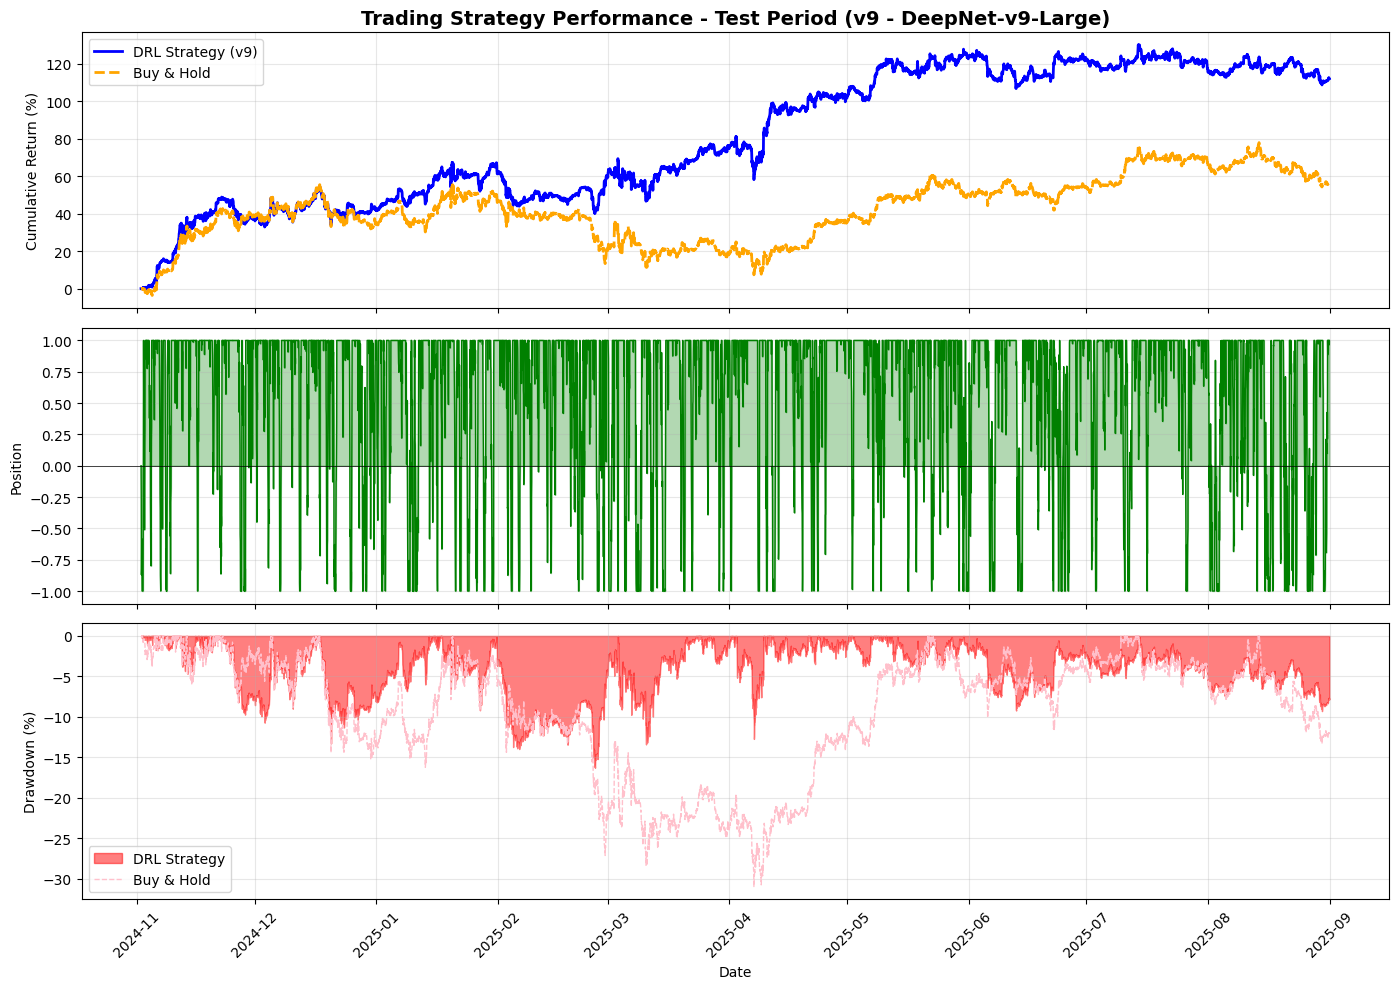


📊 Chart saved to: performance_chart_v9.png


In [ ]:
# 累積リターン曲線
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=('Cumulative Returns', 'Position', 'Drawdown'),
    vertical_spacing=0.1,
    row_heights=[0.4, 0.3, 0.3]
)

# 時間軸
time_index = test_df.index[:len(strategy_results['nav_history'])]

# Buy & Hold NAVをDRL戦略と同じ長さに調整
bh_nav_aligned = bh_results['nav_history'][:len(strategy_results['nav_history'])]

# 1. 累積リターン
fig.add_trace(
    go.Scatter(
        x=time_index,
        y=(strategy_results['nav_history'] - 1) * 100,
        mode='lines',
        name='DRL Strategy (v9)',
        line=dict(color='blue', width=2)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=time_index,
        y=(bh_nav_aligned - 1) * 100,
        mode='lines',
        name='Buy & Hold',
        line=dict(color='orange', width=2, dash='dash')
    ),
    row=1, col=1
)

# 2. ポジション（DRL戦略のみ）
fig.add_trace(
    go.Scatter(
        x=time_index,
        y=strategy_results['position_history'],
        mode='lines',
        name='Position',
        line=dict(color='green', width=1),
        fill='tozeroy',
        showlegend=False
    ),
    row=2, col=1
)

# 3. ドローダウン
strategy_cummax = np.maximum.accumulate(strategy_results['nav_history'])
strategy_dd = (strategy_results['nav_history'] - strategy_cummax) / strategy_cummax * 100

bh_cummax = np.maximum.accumulate(bh_nav_aligned)
bh_dd = (bh_nav_aligned - bh_cummax) / bh_cummax * 100

fig.add_trace(
    go.Scatter(
        x=time_index,
        y=strategy_dd,
        mode='lines',
        name='DRL Drawdown',
        line=dict(color='red', width=1),
        fill='tozeroy',
        showlegend=False
    ),
    row=3, col=1
)

fig.add_trace(
    go.Scatter(
        x=time_index,
        y=bh_dd,
        mode='lines',
        name='B&H Drawdown',
        line=dict(color='pink', width=1, dash='dash'),
        showlegend=False
    ),
    row=3, col=1
)

# レイアウト
fig.update_layout(
    title=f'DRL Trading Strategy Performance (v9 - {best_hyperparameters.name})',
    height=800,
    showlegend=True,
    hovermode='x unified'
)

fig.update_xaxes(title_text='Date', row=3, col=1)
fig.update_yaxes(title_text='Return (%)', row=1, col=1)
fig.update_yaxes(title_text='Position', row=2, col=1)
fig.update_yaxes(title_text='Drawdown (%)', row=3, col=1)

fig.show()

# 静的グラフ（matplotlib）
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 累積リターン
ax1 = axes[0]
ax1.plot(time_index, (strategy_results['nav_history'] - 1) * 100, label='DRL Strategy (v9)', color='blue', linewidth=2)
ax1.plot(time_index, (bh_nav_aligned - 1) * 100, label='Buy & Hold', color='orange', linestyle='--', linewidth=2)
ax1.set_ylabel('Cumulative Return (%)')
ax1.set_title(f'Trading Strategy Performance - Test Period (v9 - {best_hyperparameters.name})', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# ポジション
ax2 = axes[1]
ax2.plot(time_index, strategy_results['position_history'], color='green', linewidth=1)
ax2.fill_between(time_index, strategy_results['position_history'], alpha=0.3, color='green')
ax2.set_ylabel('Position')
ax2.set_ylim(-1.1, 1.1)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3)

# ドローダウン
ax3 = axes[2]
ax3.fill_between(time_index, strategy_dd, alpha=0.5, color='red', label='DRL Strategy')
ax3.plot(time_index, bh_dd, color='pink', linestyle='--', linewidth=1, label='Buy & Hold')
ax3.set_ylabel('Drawdown (%)')
ax3.set_xlabel('Date')
ax3.legend(loc='lower left')
ax3.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

# 保存
save_path = '/content/performance_chart_v9.png' if IN_COLAB else 'performance_chart_v9.png'
plt.savefig(save_path, dpi=100, bbox_inches='tight')
plt.show()

print(f"\n📊 Chart saved to: {save_path}")

## 14. 最終サマリー

In [ ]:
print("\n" + "="*80)
print("🎯 FINAL SUMMARY - Deep Reinforcement Learning Trading System v9")
print("="*80)

print("\n📊 Dataset:")
print(f"   Symbol: BTCUSDT Perpetual (Bybit)")
print(f"   Timeframe: 1 hour")
print(f"   Total period: {df_features.index[0]} to {df_features.index[-1]}")
print(f"   Train samples: {len(train_df):,}")
print(f"   Test samples: {len(test_df):,}")

print("\n🤖 Model:")
print(f"   Algorithm: PPO with Risk-Aware Composite Rewards")
print(f"   Hyperparameter Sets Tested: {len(HYPERPARAMETER_SETS)}")
print(f"   Selected Hyperparameters: {best_hyperparameters.name}")
print(f"   Selection Metric: Calmar Ratio (return/max_drawdown)")
print(f"   Walk-Forward steps: {len(wfo_splits)}")
print(f"   Features: {len(feature_columns)} (with regime detection & order flow)")
print(f"   Action space: Continuous [-1, +1]")
print(f"   Final timesteps: {final_timesteps:,} (dynamic)")

print("\n💰 Trading Parameters:")
print(f"   Initial capital: {INITIAL_CAPITAL}")
print(f"   Taker fee: {TAKER_FEE*100:.2f}% (手数料なし)")
print(f"   Leverage: {LEVERAGE}x")
print(f"   Execution: {EXECUTION_PRICE}")

print("\n🏆 Test Period Results:")
print("\n   DRL Strategy (v9):")
print(f"     - Total Return: {strategy_results['total_return']*100:+.2f}%")
print(f"     - Calmar Ratio: {strategy_results['calmar_ratio']:.3f}")
print(f"     - Sortino Ratio: {strategy_results['sortino_ratio']:.3f}")
print(f"     - Sharpe Ratio: {strategy_results['sharpe_ratio']:.3f}")
print(f"     - Max Drawdown: {strategy_results['max_drawdown']*100:.2f}%")
print(f"     - Win Rate: {strategy_results['win_rate']*100:.1f}%")
print(f"     - Profit Factor: {strategy_results.get('profit_factor', 0):.2f}")
print(f"     - Trades: {strategy_results['n_trades']}")

print("\n   Buy & Hold:")
print(f"     - Total Return: {bh_results['total_return']*100:+.2f}%")
print(f"     - Calmar Ratio: {bh_results['calmar_ratio']:.3f}")
print(f"     - Sortino Ratio: {bh_results['sortino_ratio']:.3f}")
print(f"     - Sharpe Ratio: {bh_results['sharpe_ratio']:.3f}")
print(f"     - Max Drawdown: {bh_results['max_drawdown']*100:.2f}%")

print("\n🎓 Key Improvements in v9:")
print("   1. Composite risk-aware reward function (no Sharpe in rewards)")
print("   2. Calmar ratio for hyperparameter selection (not Sharpe)")
print("   3. Enhanced features: regime detection, order flow imbalance")
print("   4. Larger neural networks (up to 1024 units)")
print("   5. Downside risk penalties and consistency bonuses")
print("   6. Recovery and momentum rewards")

print("\n📁 Output Files:")
if IN_COLAB:
    print("   - /content/final_model_ppo_v9.zip (trained model)")
    print("   - /content/final_scaler_v9.pkl (feature scaler)")
    print("   - /content/performance_chart_v9.png")
else:
    print("   - final_model_ppo_v9.zip (trained model)")
    print("   - final_scaler_v9.pkl (feature scaler)")
    print("   - performance_chart_v9.png")

print("\n⚠️  Disclaimer:")
print("   This is for educational purposes only. Not financial advice.")
print("   Past performance does not guarantee future results.")
print("   Cryptocurrency trading involves substantial risk of loss.")

print("\n✅ Analysis Complete!")
print("="*80)


🎯 FINAL SUMMARY - Deep Reinforcement Learning Trading System v9

📊 Dataset:
   Symbol: BTCUSDT Perpetual (Bybit)
   Timeframe: 1 hour
   Total period: 2020-09-09 08:00:00+00:00 to 2025-08-31 23:00:00+00:00
   Train samples: 36,353
   Test samples: 7,271

🤖 Model:
   Algorithm: PPO with Risk-Aware Composite Rewards
   Hyperparameter Sets Tested: 4
   Selected Hyperparameters: DeepNet-v9-Large
   Selection Metric: Calmar Ratio (return/max_drawdown)
   Walk-Forward steps: 4
   Features: 49 (with regime detection & order flow)
   Action space: Continuous [-1, +1]
   Final timesteps: 545,295 (dynamic)

💰 Trading Parameters:
   Initial capital: 1.0
   Taker fee: 0.00% (手数料なし)
   Leverage: 1.0x
   Execution: next_open

🏆 Test Period Results:

   DRL Strategy (v9):
     - Total Return: +111.89%
     - Calmar Ratio: 9.033
     - Sortino Ratio: 2.961
     - Sharpe Ratio: 2.336
     - Max Drawdown: -16.29%
     - Win Rate: 51.2%
     - Profit Factor: 1.09
     - Trades: 3425

   Buy & Hold:
    